In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import font_manager

plt.rcParams.update({
    "figure.dpi": 200,
    "text.usetex": False,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif", "Computer Modern Roman"],
    "mathtext.fontset": "cm",

    "axes.linewidth": 1.2,
    "axes.labelsize": 20,
    "axes.titlesize": 20,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

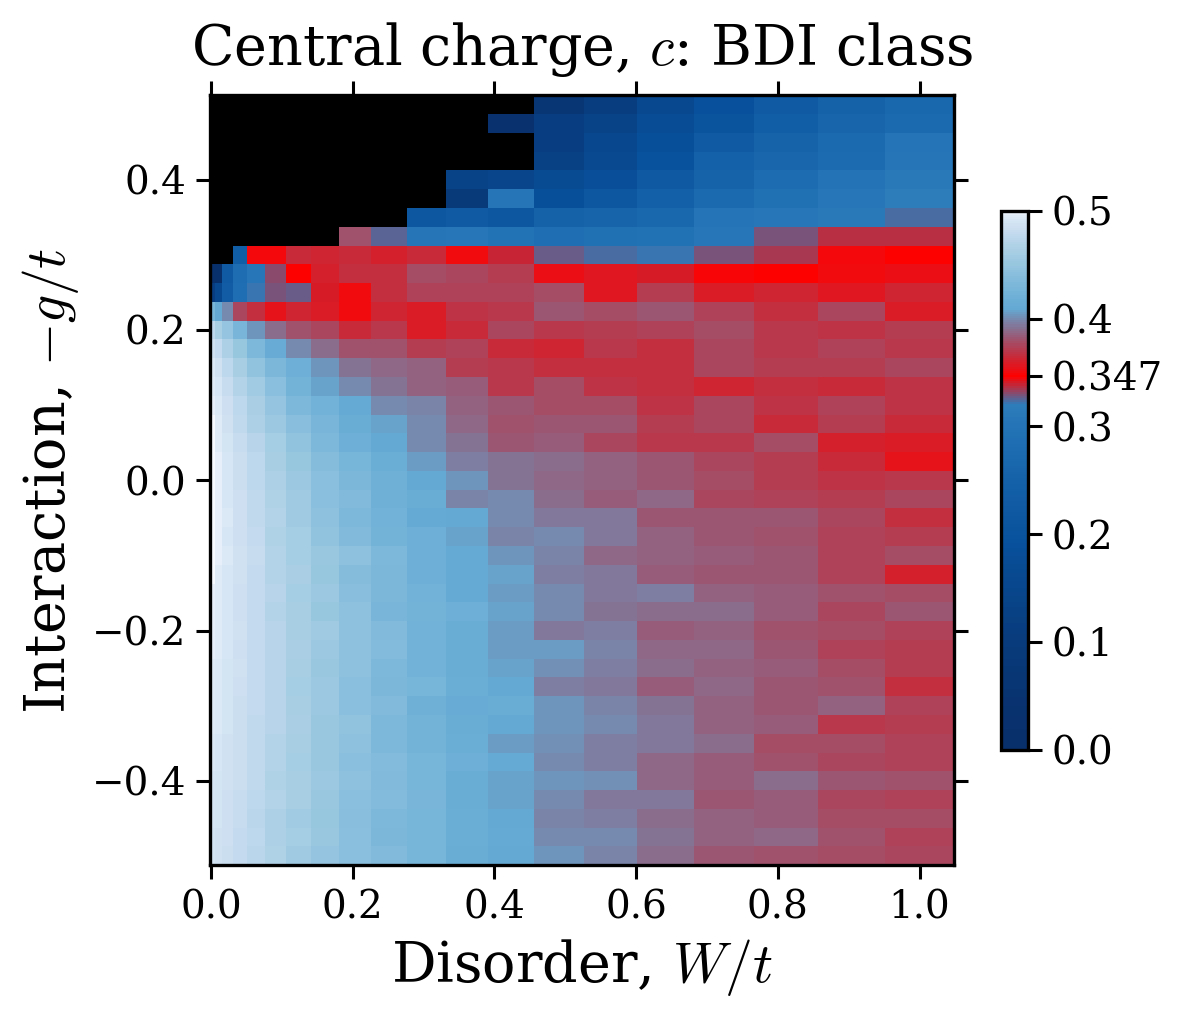

In [ ]:
#____plotting W-g map for central charge. Fully critical Majoranan chain model in D class (L=500 Majoranas)______


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import font_manager



path = Path("../mean_field_data/raw/data_fully_critical_chain_BDI/").expanduser()
data = np.load(path/"500_majoranas_c.npy")


WX_range = np.asarray([i**2/400 for i in range(21)])
g_values = np.linspace(-0.5, 0.5, 41)
c_data=np.asarray(data)

# Color normalization and fade region definition
vmin, vmax = 0.0, 0.5
fade_start = 0.32
fade_mid = 0.5*np.log(2)
fade_end = 0.41

# Define a colormap: Blues with smoothly blended red overlay from 0.33 to 0.38
def blues_with_faded_red_overlay():
    base_cmap = plt.cm.Blues_r  
    n = 256
    colors = []

    for i in range(n):
        val = vmin + (vmax - vmin) * i / (n - 1)
        base_color = base_cmap((np.arcsin((val - vmin) / (vmax - vmin))*2/np.pi)**1.5)
        r0, g0, b0, a0 = base_color

        if fade_start <= val <= fade_end:
            if val <= fade_mid:
                weight = (val - fade_start) / (fade_mid - fade_start)  # fade in
            else:
                weight = (fade_end - val) / (fade_end - fade_mid)      # fade out

            weight=weight  
            r = (1.0 * weight + r0 * (1 - weight))
            g = (0.0 * weight + g0 * (1 - weight))
            b = (0.0 * weight + b0 * (1 - weight))
            colors.append((r, g, b, 1.0))
        else:
            colors.append(base_color)

    return LinearSegmentedColormap.from_list("blues_faded_red", colors, N=n)

# Create colormap and normalization
cmap = blues_with_faded_red_overlay()
cmap.set_bad('black')
norm = Normalize(vmin=vmin, vmax=vmax)


# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'Central charge, $ c$: BDI class', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# Format the colorbar ticks to 3 decimal places
import matplotlib.ticker as ticker



import matplotlib.colors as mcolors
c_data=np.asarray(c_data)

nan_mask = np.isnan(c_data)

combined_mask = nan_mask #| energy_mask

c_data_masked = np.ma.masked_where(combined_mask, c_data)
pl0 = ax.pcolormesh(WX_range, g_values, c_data_masked.T, cmap=cmap, norm=norm)

# Colorbar
ticks = [0.0, 0.1, 0.2, 0.3, 0.347, 0.4, 0.5]
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional", ticks=ticks)


tick_labels = [f"{t:.3f}" if abs(t - 0.347) < 1e-6 else f"{t:.1f}" for t in ticks]
cbar.ax.set_yticklabels(tick_labels)
ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)

plt.show()


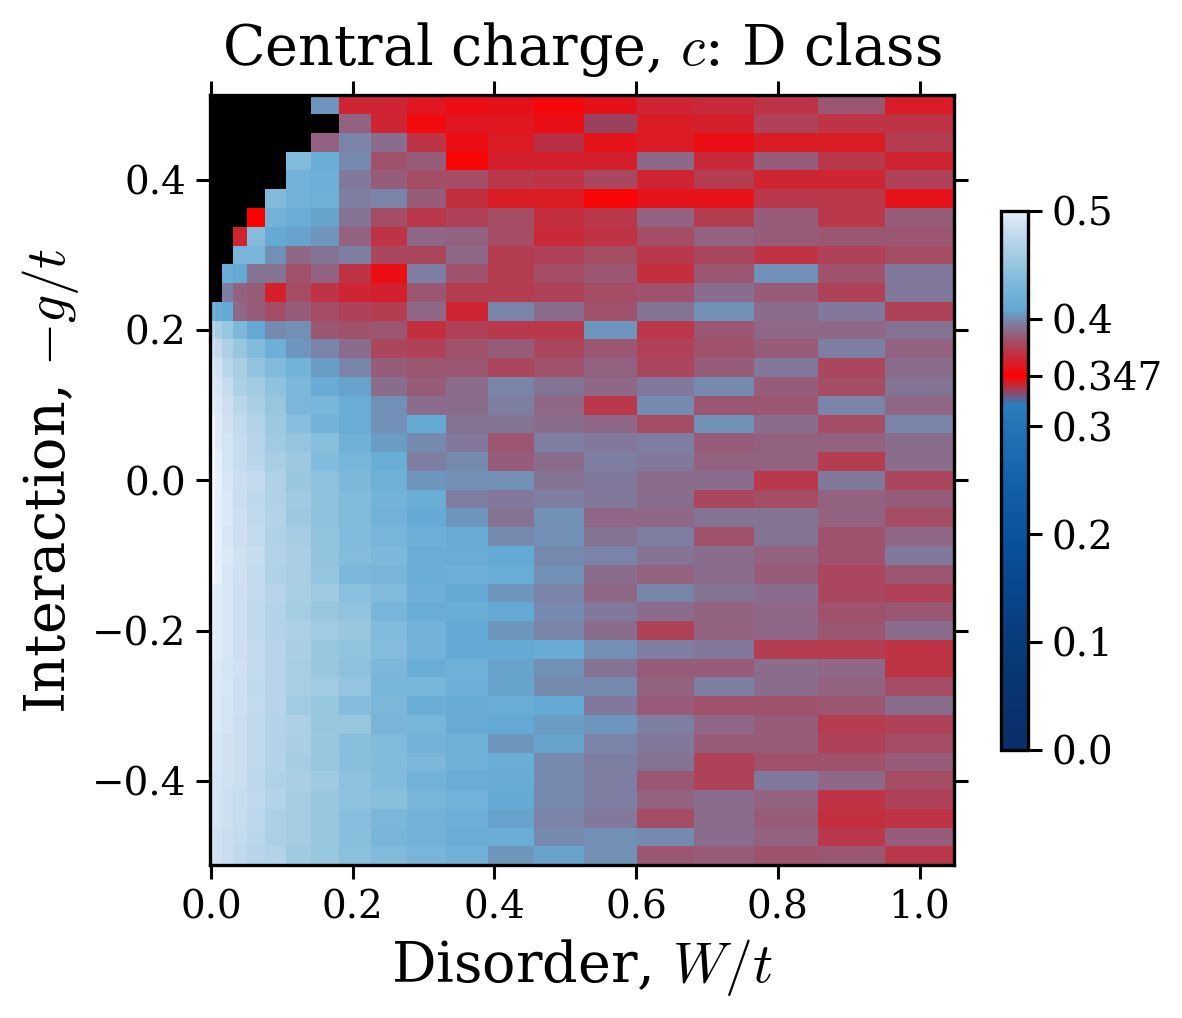

In [ ]:
#____plotting W-g map for central charge. Fully critical Majoranan chain model in D class (L=500 Majoranas)______


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import font_manager


path = Path("../mean_field_data/raw/data_fully_critical_chain_D/").expanduser()
data = np.load(path/"500_majoranas_c.npy")


WX_range = np.asarray([i**2/400 for i in range(21)])
g_values = np.linspace(-0.5, 0.5, 41)
c_data=np.asarray(data)

# Color normalization and fade region definition
vmin, vmax = 0.0, 0.5
fade_start = 0.32
fade_mid = 0.5*np.log(2)
fade_end = 0.41

# Define a colormap: Blues with smoothly blended red overlay from 0.33 to 0.38
def blues_with_faded_red_overlay():
    base_cmap = plt.cm.Blues_r   
    n = 256
    colors = []

    for i in range(n):
        val = vmin + (vmax - vmin) * i / (n - 1)
        base_color = base_cmap((np.arcsin((val - vmin) / (vmax - vmin))*2/np.pi)**1.5)
        r0, g0, b0, a0 = base_color

        if fade_start <= val <= fade_end:
            if val <= fade_mid:
                weight = (val - fade_start) / (fade_mid - fade_start)  # fade in
            else:
                weight = (fade_end - val) / (fade_end - fade_mid)      # fade out

            weight=weight #**0.8
            r = (1.0 * weight + r0 * (1 - weight))
            g = (0.0 * weight + g0 * (1 - weight))
            b = (0.0 * weight + b0 * (1 - weight))
            colors.append((r, g, b, 1.0))
        else:
            colors.append(base_color)

    return LinearSegmentedColormap.from_list("blues_faded_red", colors, N=n)

# Create colormap and normalization
cmap = blues_with_faded_red_overlay()
cmap.set_bad('black')
norm = Normalize(vmin=vmin, vmax=vmax)


# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'Central charge, $ c$: D class', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# Format the colorbar ticks to 3 decimal places
import matplotlib.ticker as ticker



import matplotlib.colors as mcolors
c_data=np.asarray(c_data)

nan_mask = np.isnan(c_data)

combined_mask = nan_mask #| energy_mask

c_data_masked = np.ma.masked_where(combined_mask, c_data)
pl0 = ax.pcolormesh(WX_range, g_values, c_data_masked.T, cmap=cmap, norm=norm)

# Colorbar
ticks = [0.0, 0.1, 0.2, 0.3, 0.347, 0.4, 0.5]
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional", ticks=ticks)


tick_labels = [f"{t:.3f}" if abs(t - 0.347) < 1e-6 else f"{t:.1f}" for t in ticks]
cbar.ax.set_yticklabels(tick_labels)
ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)

plt.show()


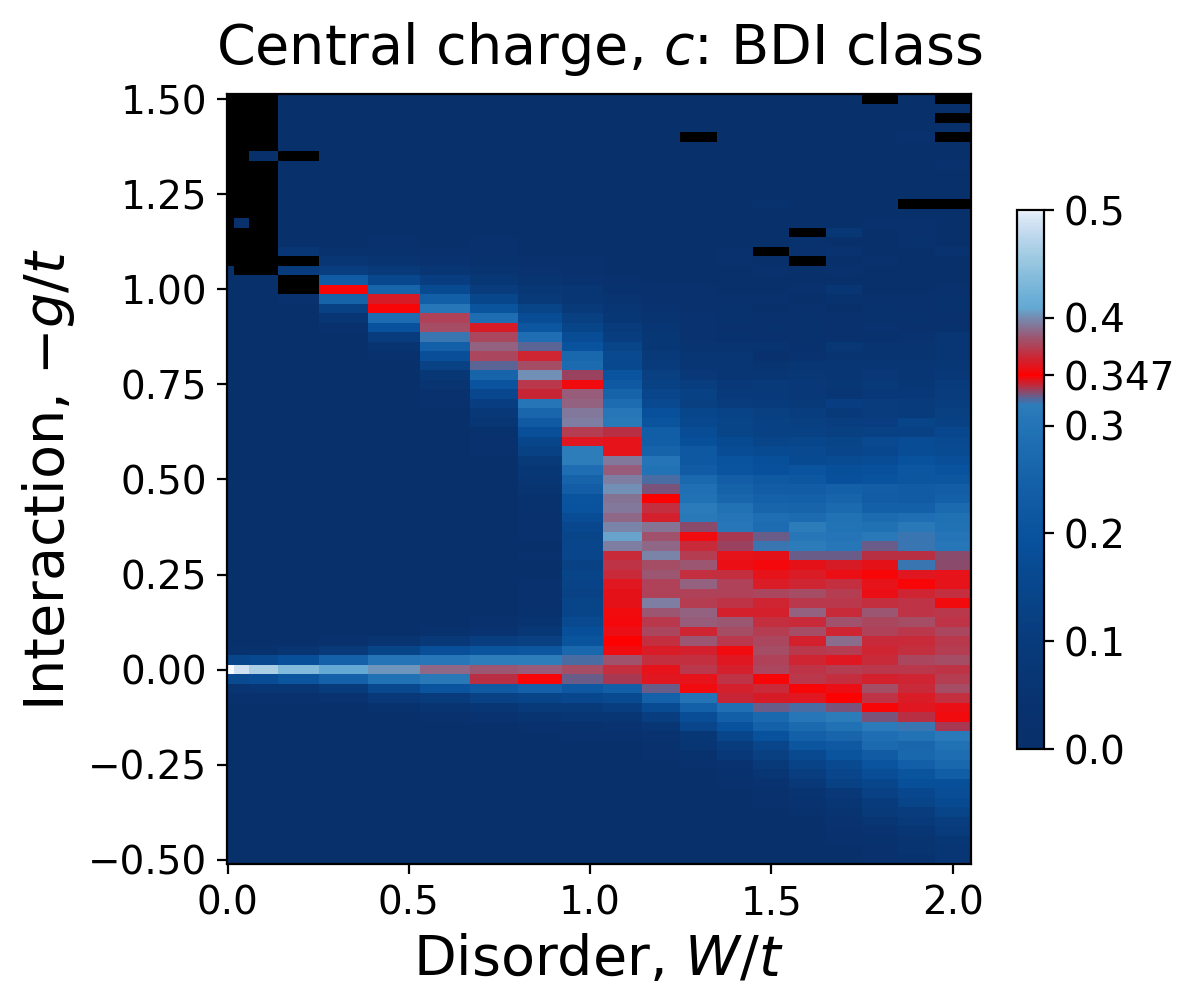

In [ ]:
#____plotting W-g map for central charge. Majorana-Hubbard model in BDI class (L=400 Majoranas)______


import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

plt.rcParams["figure.dpi"] = 200
plt.rcParams["text.usetex"] = True

plt.rc("font", family="", size=12)
plt.rc("text", usetex=False)



path = Path("../mean_field_data/raw/data_Majorana_Hubbard_chain_BDI/").expanduser()
data = np.load(path/"400_majoranas_c.npy")


WX_range = np.asarray([(i/10)*(1-np.exp(-4*(i/10)**2)) for i in range(21)])
g_values = np.linspace(-0.5, 1.5, 81)
c_data=np.asarray(data)

# Color normalization and fade region definition
vmin, vmax = 0.0, 0.5
fade_start = 0.32
fade_mid = 0.5*np.log(2)
fade_end = 0.41

# Define a colormap: Blues with smoothly blended red overlay from 0.33 to 0.38
def blues_with_faded_red_overlay():
    base_cmap = plt.cm.Blues_r  
    n = 256
    colors = []

    for i in range(n):
        val = vmin + (vmax - vmin) * i / (n - 1)
        base_color = base_cmap((np.arcsin((val - vmin) / (vmax - vmin))*2/np.pi)**1.5)
        r0, g0, b0, a0 = base_color

        if fade_start <= val <= fade_end:
            if val <= fade_mid:
                weight = (val - fade_start) / (fade_mid - fade_start)  # fade in
            else:
                weight = (fade_end - val) / (fade_end - fade_mid)      # fade out

            weight=weight # **0.8
            r = (1.0 * weight + r0 * (1 - weight))
            g = (0.0 * weight + g0 * (1 - weight))
            b = (0.0 * weight + b0 * (1 - weight))
            colors.append((r, g, b, 1.0))
        else:
            colors.append(base_color)

    return LinearSegmentedColormap.from_list("blues_faded_red", colors, N=n)

# Create colormap and normalization
cmap = blues_with_faded_red_overlay()
cmap.set_bad('black')
norm = Normalize(vmin=vmin, vmax=vmax)


# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'Central charge, $ c$: BDI class', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# Format the colorbar ticks to 3 decimal places
import matplotlib.ticker as ticker




import matplotlib.colors as mcolors
c_data=np.asarray(c_data)
nan_mask = np.isnan(c_data)
combined_mask = nan_mask #| energy_mask

c_data_masked = np.ma.masked_where(combined_mask, c_data)
pl0 = ax.pcolormesh(WX_range, g_values, c_data_masked.T, cmap=cmap, norm=norm)

# Colorbar
ticks = [0.0, 0.1, 0.2, 0.3, 0.347, 0.4, 0.5]
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional", ticks=ticks)


tick_labels = [f"{t:.3f}" if abs(t - 0.347) < 1e-6 else f"{t:.1f}" for t in ticks]
cbar.ax.set_yticklabels(tick_labels)
ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)


plt.show()


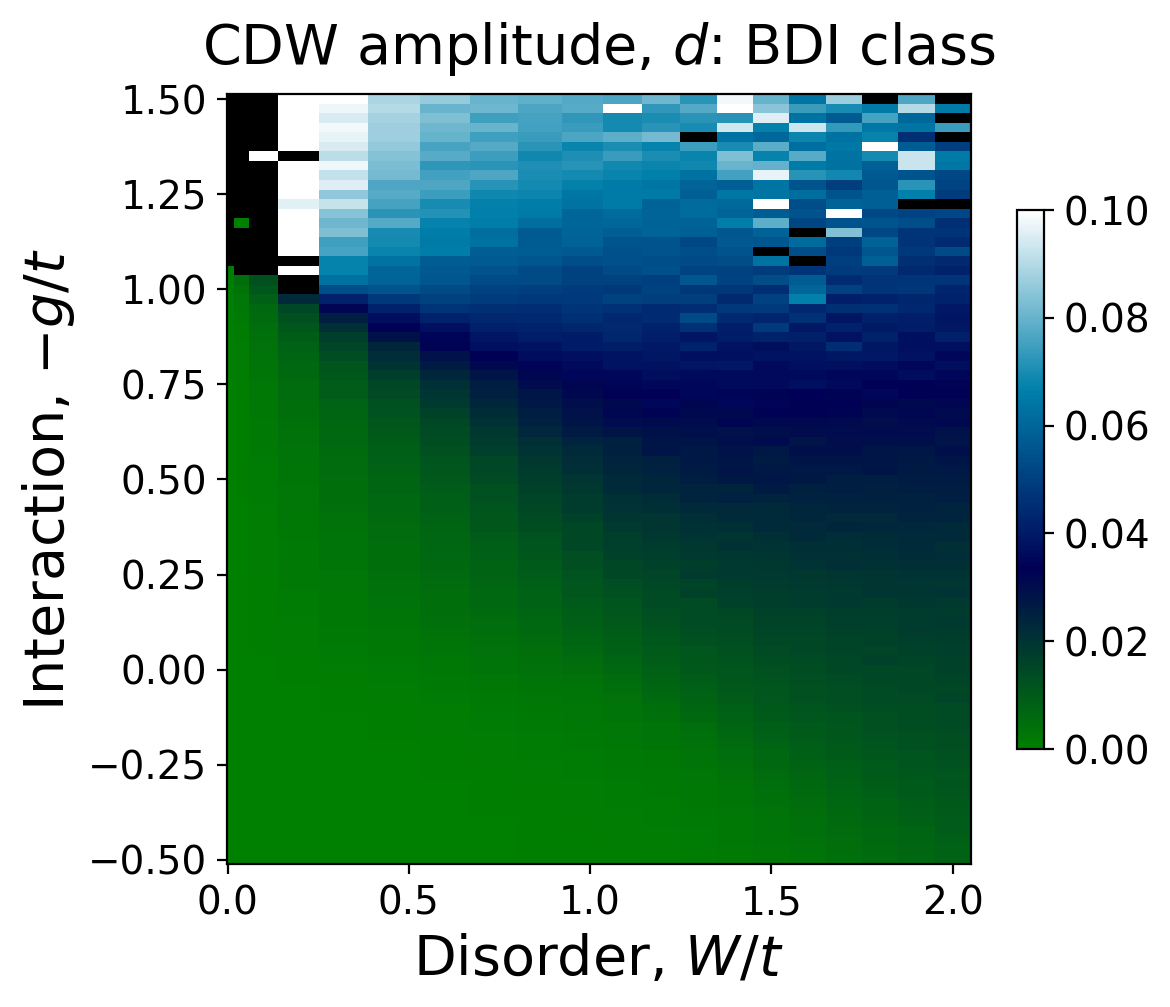

In [ ]:
#____plotting W-g CDW phase diagram for Majorana-Hubbard model in BDI class  (L=400 Majoranas)______


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
from matplotlib import font_manager


path = Path("../mean_field_data/raw/data_Majorana_Hubbard_chain_BDI/").expanduser()
data_cdw = np.max(np.load(path/"400_nk_env_mean.npy")[:,:,-5:-1], axis=2)/200 




WX_range = np.asarray([i**2/400 for i in range(21)])
WX_range = np.asarray([i/10 for i in range(21)])
WX_range = np.asarray([(i/10)*(1-np.exp(-4*(i/10)**2)) for i in range(21)])

g_values = np.linspace(-0.5, 1.5, 81)


pltp.rc('font', family='', size=12)
pltp.rc('text', usetex=False)   



cmap = plt.cm.seismic  


# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'CDW amplitude, $d$: BDI class', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# Format the colorbar ticks to 3 decimal places
import matplotlib.ticker as ticker



import matplotlib.colors as mcolors
data_cdw=np.asarray(data_cdw)
nan_mask = np.isnan(data_cdw)
inf_mask = np.isinf(data_cdw)
combined_mask = nan_mask | inf_mask
combined_mask = nan_mask #| energy_mask

cdw_data_masked = np.ma.masked_where(combined_mask, data_cdw)
cmap = plt.cm.ocean.copy()   
cmap.set_bad(color='black')
pl0 = ax.pcolormesh(WX_range, g_values,  np.clip(cdw_data_masked.T,0,0.1), cmap=cmap)

# Colorbar
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional")
ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)



plt.show()


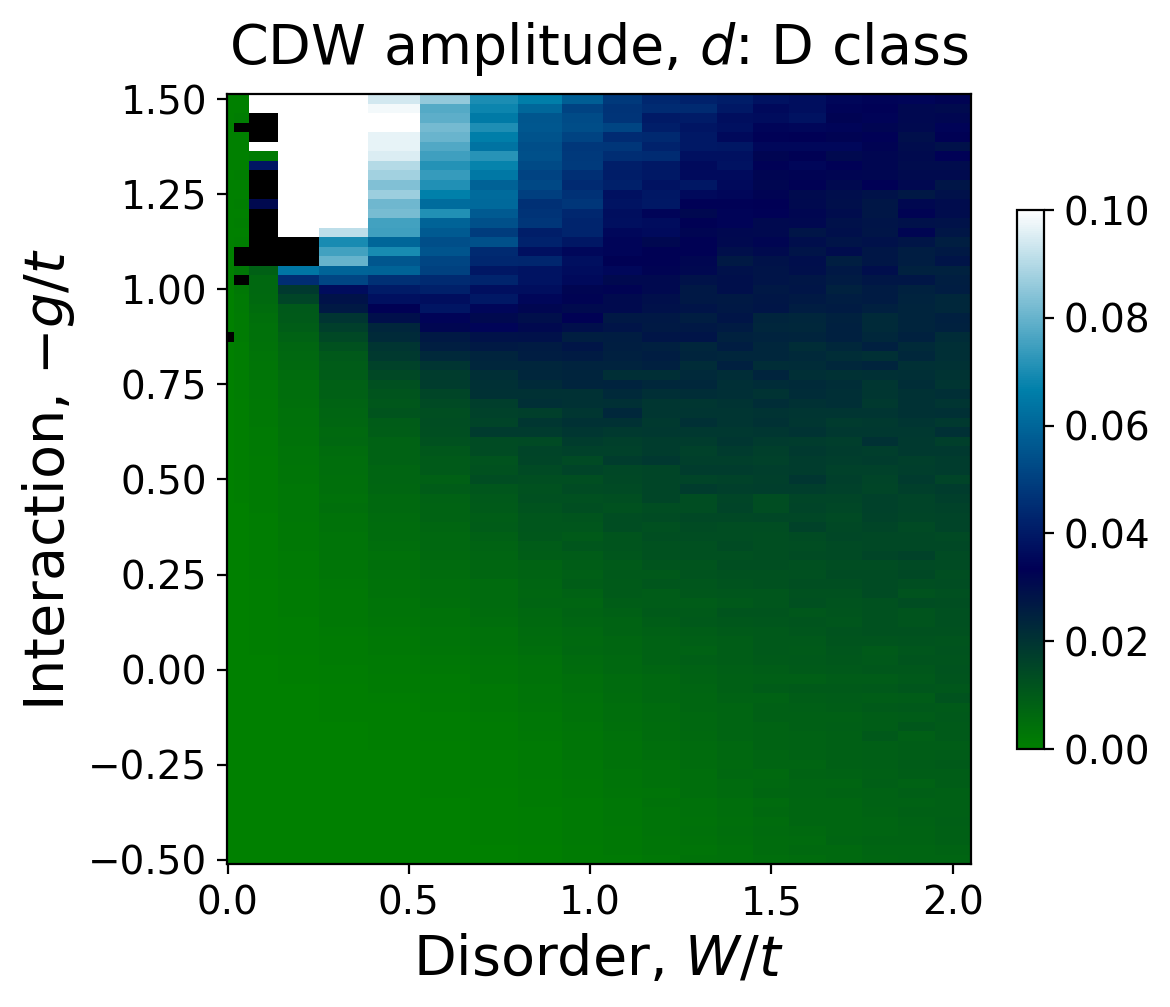

In [ ]:
#____plotting W-g CDW phase diagram for Majorana-Hubbard model in D class  (L=400 Majoranas)______


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
from matplotlib import font_manager



path = Path("../mean_field_data/raw/data_Majorana_Hubbard_chain_D/").expanduser()
data_cdw = np.max(np.load(path/"400_nk_env_mean.npy")[:,:,-5:-1], axis=2)/200 

WX_range = np.asarray([(i/10)*(1-np.exp(-4*(i/10)**2)) for i in range(21)])
g_values = np.linspace(-0.5, 1.5, 81)


pltp.rc('font', family='', size=12)
pltp.rc('text', usetex=False)   



cmap = plt.cm.seismic  


# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'CDW amplitude, $d$: D class', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# Format the colorbar ticks to 3 decimal places
import matplotlib.ticker as ticker



import matplotlib.colors as mcolors
data_cdw=np.asarray(data_cdw)
nan_mask = np.isnan(data_cdw)
inf_mask = np.isinf(data_cdw)
combined_mask = nan_mask | inf_mask
combined_mask = nan_mask #| energy_mask

cdw_data_masked = np.ma.masked_where(combined_mask, data_cdw)
cmap = plt.cm.ocean.copy()  #PRGn
cmap.set_bad(color='black')
pl0 = ax.pcolormesh(WX_range, g_values,  np.clip(cdw_data_masked.T,0,0.1), cmap=cmap)

# Colorbar
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional")
ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)



plt.show()


findfont: Font family [] not found. Falling back to DejaVu Sans.


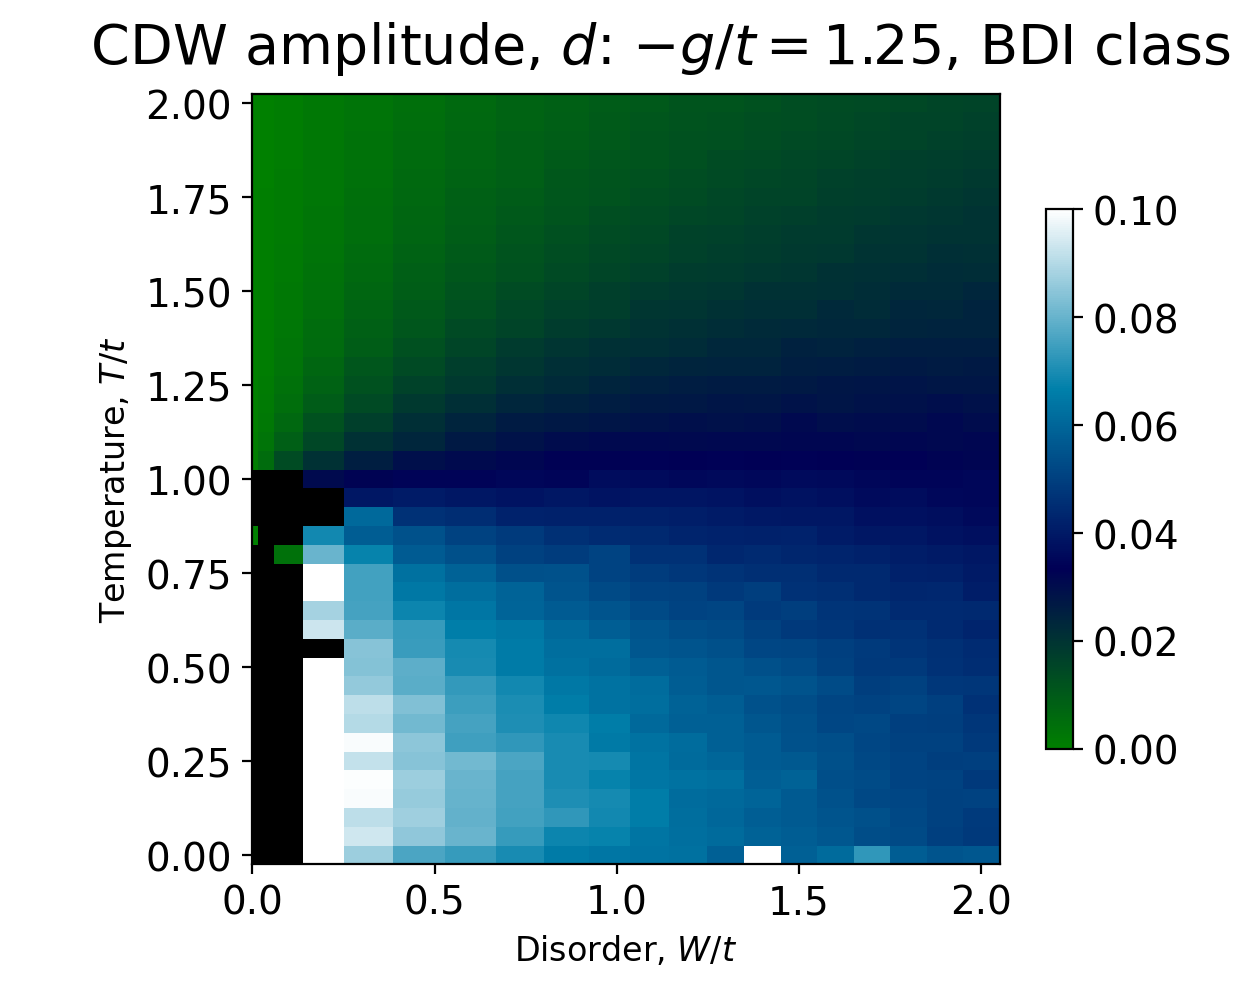

In [ ]:
#____plotting W-T CDW phase diagram for Majorana-Hubbard model in BDI class  (L=400 Majoranas)______

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

plt.rcParams["figure.dpi"] = 200
plt.rcParams["text.usetex"] = True

plt.rc("font", family="", size=12)
plt.rc("text", usetex=False)

# ============================================================
# Path and data
# ============================================================


L = 200 # complex fermion number (2*L Majorana sites)

g_fixed = 1.25 # CDW state for clean limit

path = Path("../mean_field_data/raw/data_CDW_temperature_map_Majorana_Hubbard_chain_BDI/").expanduser()


data_cdw = np.load(path / f"{2 * L}_fixed_g_{g_fixed}_cdw_WT.npy")
data_cdw = np.max(np.load(path / f"{2 * L}_fixed_g_{g_fixed}_nk_env_mean_WT.npy")[:,:, -5:-1],axis=2)/L



# ============================================================
# W and T grids
# ============================================================


WX_range = np.asarray([(i/10)*(1-np.exp(-4*(i/10)**2)) for i in range(21)])  
T_values = np.linspace(0.0, 2, 41)


# ============================================================
# Plot settings
# ============================================================

data_cdw = np.asarray(data_cdw)

nan_mask = np.isnan(data_cdw)
inf_mask = np.isinf(data_cdw)
combined_mask = nan_mask | inf_mask

cdw_data_masked = np.ma.masked_where(combined_mask, data_cdw)

cmap = plt.cm.ocean.copy()
cmap.set_bad(color="black")

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(5.8, 5.1))

ax.set_title(rf"    CDW amplitude, $d$: $-g/t={g_fixed}$, BDI class", fontsize=20, va="bottom")
ax.set_xlabel(r"Disorder, $W/t$" )
ax.set_ylabel(r"Temperature, $T/t$" )

pl0 = ax.pcolormesh(
    WX_range,
    T_values,
    np.clip(cdw_data_masked.T, 0, 0.1),
    cmap=cmap,
    shading="auto",
)

cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional")

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

ax.tick_params(axis="both", labelsize=14)
cbar.ax.tick_params(labelsize=14)

fig.tight_layout()

plt.show()

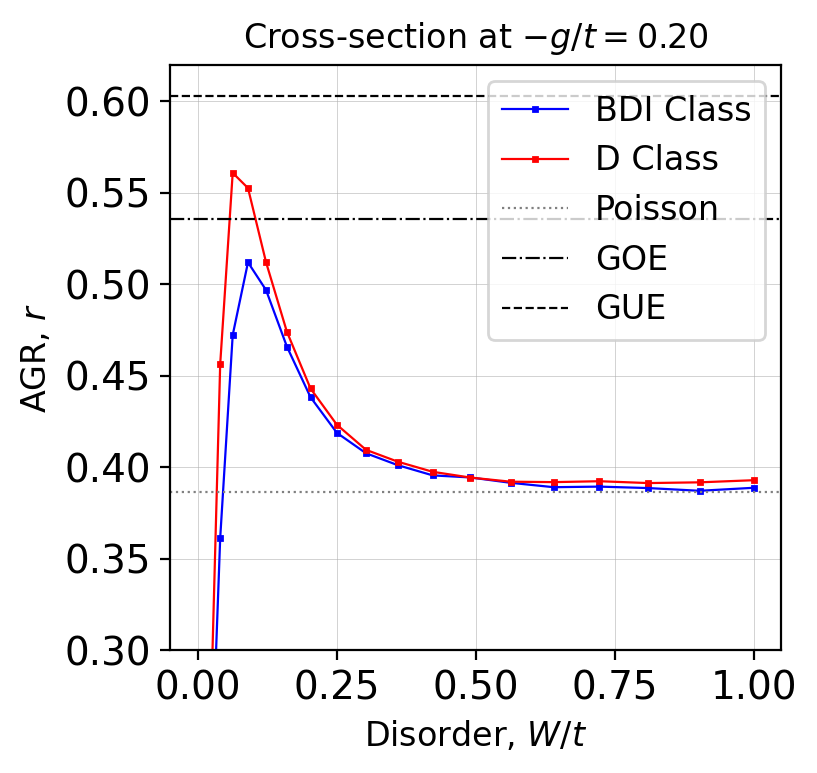

In [ ]:
#_____Demonstration of AGR peak at (-g/t)~0.2 in critical chains (BDI and D symmetry classes)________


import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from pathlib import Path

# Constants
r_poiss = 2 * np.log(2) - 1
r_goe = 4 - 2 * np.sqrt(3)
r_gue = 2 * np.sqrt(3) / np.pi - 0.5

# Plot settings
plt.rcParams["figure.dpi"] = 200
plt.rcParams['text.usetex'] = False
plt.rc('font', size=12)

# Load data
path = Path("../mean_field_data/raw/data_fully_critical_chain_BDI/").expanduser()
Ls = [ 500]
data_dict_BDI = {L: np.asarray(np.load(path / f"{L}_majoranas_agr.npy")) for L in Ls}

# Load data
path = Path("../mean_field_data/raw/data_fully_critical_chain_D/").expanduser()
data_dict_D = {L: np.asarray(np.load(path / f"{L}_majoranas_agr.npy")) for L in Ls}

# Axes
WX_range = np.array([i**2 / 400 for i in range(21)])  # 0.0 to 1.0
g_values = np.linspace(-0.5, 0.5, 41)

# Mask invalid values
masked_data_BDI = {L: np.ma.masked_invalid(data) for L, data in data_dict_BDI.items()}
masked_data_D = {L: np.ma.masked_invalid(data) for L, data in data_dict_D.items()}

# === Choose a fixed W value ===
g_target = g_values[28]
g_idx = np.argmin(np.abs(g_values - g_target))

# === Plot overlaid 1D slices at fixed W ===
plt.figure(figsize=(4, 4))

for L in Ls:
    r_vals_BDI = data_dict_BDI[L][:, g_idx]  # shape: (41,) — correct
    r_vals_D = data_dict_D[L][:, g_idx]  # shape: (41,) — correct
    plt.plot(WX_range, r_vals_BDI, 's-',color='blue', markersize=1.2, linewidth=0.8, label="BDI Class")
    plt.plot(WX_range, r_vals_D, 's-',color='red', markersize=1.2, linewidth=0.8, label="D Class")
    




# Reference lines
plt.axhline(r_poiss, color='gray', linestyle=':', linewidth=0.8, label=r'Poisson')
plt.axhline(r_goe, color='black', linestyle='-.', linewidth=0.8, label=r'GOE')
plt.axhline(r_gue, color='black', linestyle='--', linewidth=0.8, label=r'GUE')

# Labels
plt.xlabel(r"Disorder, $W/t$", fontsize=12)
plt.ylabel(r"AGR, $ r $", fontsize=12)
plt.title(fr"Cross-section at $-g/t = {g_target:.2f}$", fontsize=12)
plt.legend()
plt.grid(linewidth=0.2)
plt.tight_layout()
plt.tick_params(axis="both", labelsize=14)

plt.ylim(0.3, 0.62)
plt.show()



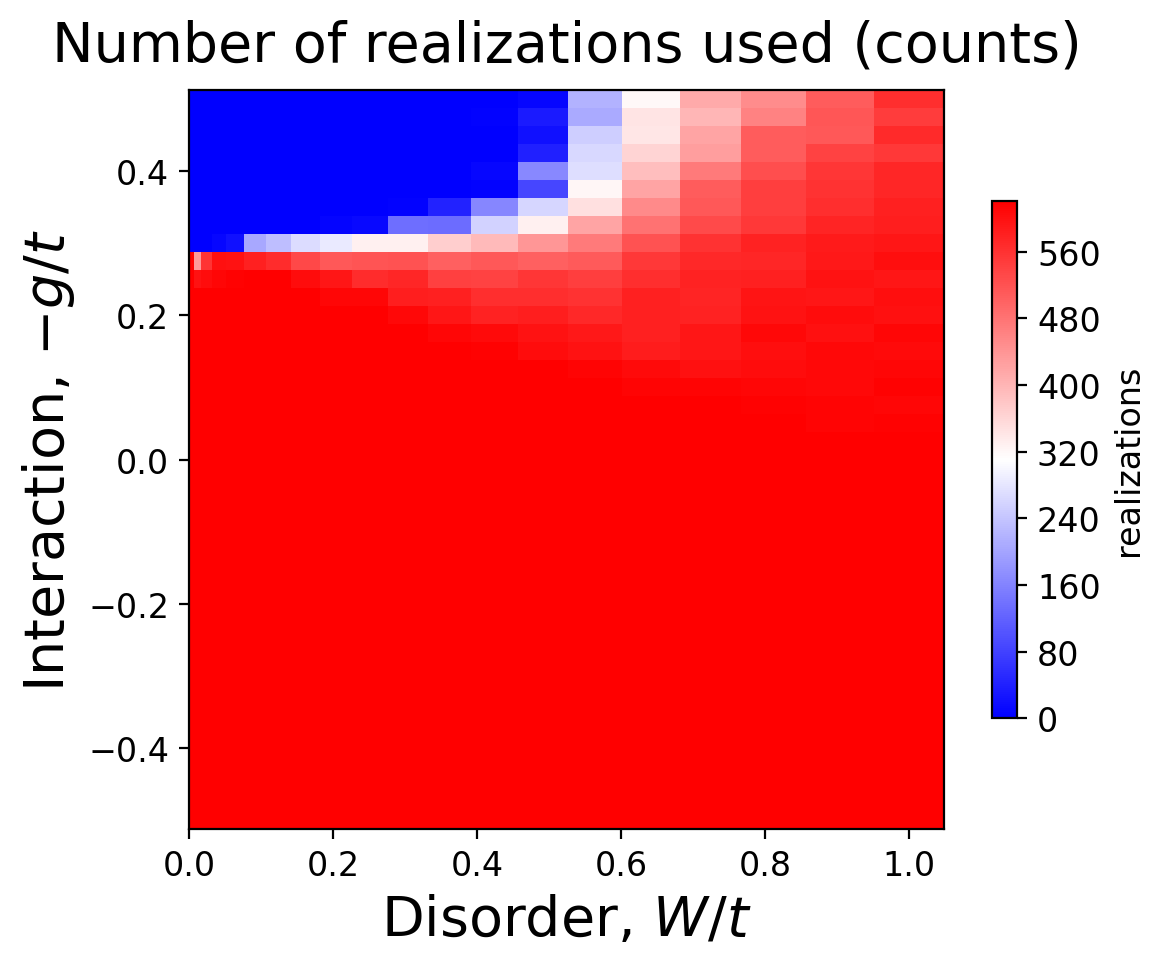

In [ ]:
#__________Counts number for fully critical chain in BDI class

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
plt.rcParams['text.usetex'] = False
from matplotlib import font_manager
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

# ---------- Paths & Data ----------
path = Path("../mean_field_data/raw/data_fully_critical_chain_BDI/").expanduser()

# Load counts (number of realizations used per grid point)
data = np.load(path / "500_majoranas_counts.npy")  
counts_data = np.asarray(data)

# Grids
WX_range = np.asarray([i**2/400 for i in range(21)])
g_values = np.linspace(-0.5, 0.5, 41)

# ---------- Plot Settings ----------
pltp.rc('font', family='', size=12)
pltp.rc('text', usetex=False)

class nlcmap(LinearSegmentedColormap):
    """A nonlinear colormap (kept from your template; unused here)."""
    name = 'nlcmap'
    def __init__(self, cmap, levels):
        self.cmap = cmap
        self.N = cmap.N
        self.monochrome = self.cmap.monochrome
        self.levels = np.asarray(levels, dtype='float64')
        self._x = self.levels / self.levels.max()
        self._y = np.linspace(-1.0, 1.0, len(self.levels))
    def __call__(self, xi, alpha=1.0, **kw):
        yi = np.interp(xi, self._x, self._y)
        return self.cmap(yi, alpha)

# Mask NaNs (inactive or never-updated points show as black)
nan_mask = np.isnan(counts_data)
counts_data_masked = np.ma.masked_where(nan_mask, counts_data)

# Choose colormap  
cmap = plt.cm.bwr
cmap = cmap.copy()
cmap.set_bad(color='black')

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'Number of realizations used (counts)', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# pcolormesh  plotting
pl0 = ax.pcolormesh(WX_range, g_values, counts_data_masked.T, cmap=cmap, shading='auto')

# Colorbar  
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional")
cbar.set_label("realizations", rotation=90)
cbar.locator = MaxNLocator(integer=True)  
cbar.update_ticks()
plt.tight_layout()
plt.show()


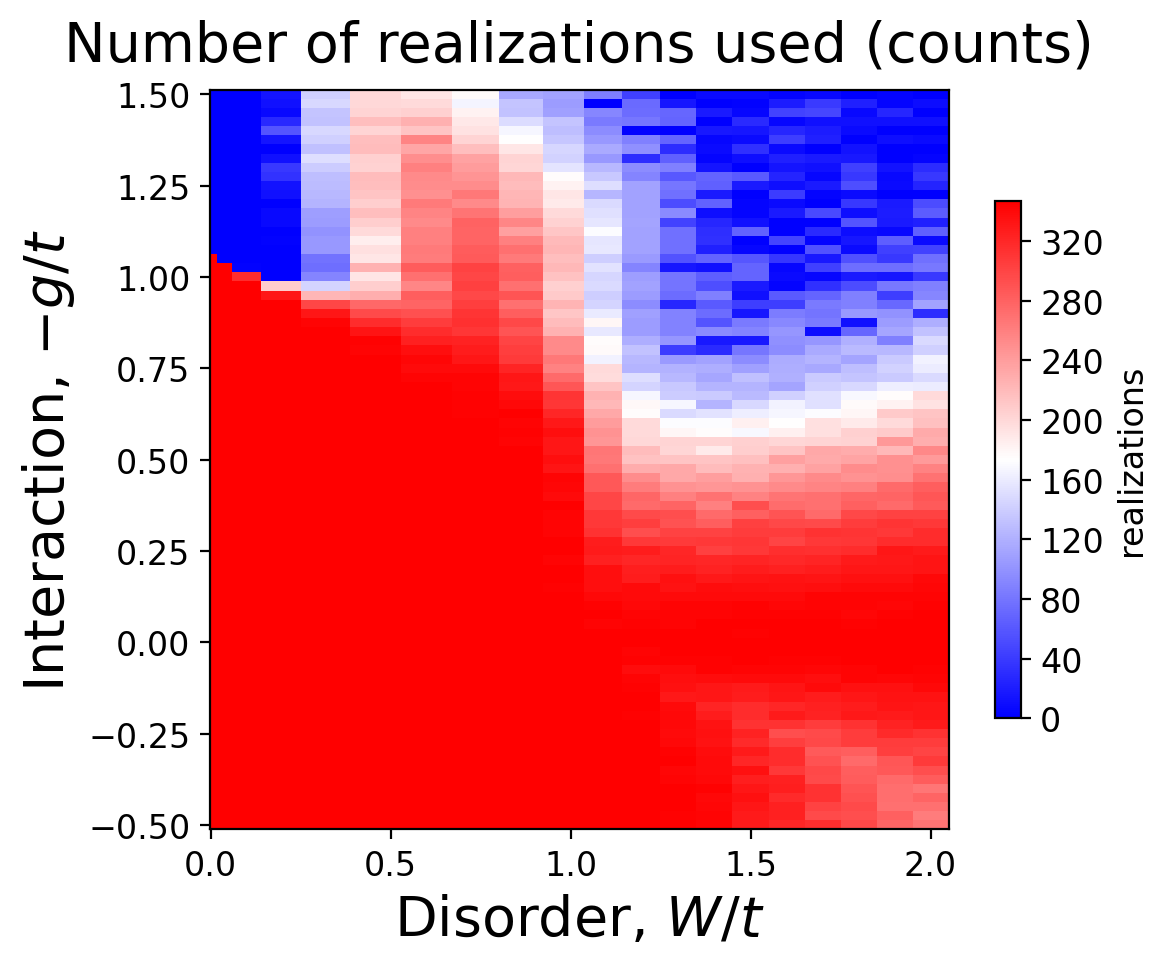

In [ ]:
#__________Counts number for Majorana-Hubbard chain in BDI class

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as pltp
plt.rcParams["figure.dpi"] = 200
plt.rcParams['text.usetex'] = False
from matplotlib import font_manager
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

# ---------- Paths & Data ----------

path = Path("../mean_field_data/raw/data_Majorana_Hubbard_chain_BDI/").expanduser() # Majorana-Hubbard chain in BDI class

# Load counts (number of realizations used per grid point)
data = np.load(path / "400_majoranas_counts.npy")   
counts_data = np.asarray(data)

# Grids
WX_range = np.asarray([(i/10)*(1-np.exp(-4*(i/10)**2)) for i in range(21)])
g_values = np.linspace(-0.5, 1.5, 81)

# ---------- Plot Settings ----------
pltp.rc('font', family='', size=12)
pltp.rc('text', usetex=False)

class nlcmap(LinearSegmentedColormap):
    """A nonlinear colormap (kept from your template; unused here)."""
    name = 'nlcmap'
    def __init__(self, cmap, levels):
        self.cmap = cmap
        self.N = cmap.N
        self.monochrome = self.cmap.monochrome
        self.levels = np.asarray(levels, dtype='float64')
        self._x = self.levels / self.levels.max()
        self._y = np.linspace(-1.0, 1.0, len(self.levels))
    def __call__(self, xi, alpha=1.0, **kw):
        yi = np.interp(xi, self._x, self._y)
        return self.cmap(yi, alpha)

# Mask NaNs (inactive or never-updated points show as black)
nan_mask = np.isnan(counts_data)
data_masked = np.ma.masked_where(nan_mask, counts_data)

# Choose colormap 
cmap = plt.cm.bwr
cmap = cmap.copy()
cmap.set_bad(color='black')

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title(r'Number of realizations used (counts)', fontsize=20, va='bottom')
ax.set_xlabel(r'Disorder, $ W/t$', fontsize=20)
ax.set_ylabel(r'Interaction, $ -g/ t$', fontsize=20)

# plotting via pcolormesh 
pl0 = ax.pcolormesh(WX_range, g_values, data_masked.T, cmap=cmap, shading='auto')

# Colorbar with integer-only ticks
cbar = plt.colorbar(pl0, ax=ax, shrink=0.7, spacing="proportional")
cbar.set_label("realizations", rotation=90)
cbar.locator = MaxNLocator(integer=True)   
cbar.update_ticks()
plt.tight_layout()
plt.show()
